# Hierarchical Network Visualization with Edge Gradients

This notebook creates a 500-node graph simulating a hierarchical terrorist network structure (similar to the Bin Laden network) and visualizes it with edge color gradients based on node centrality.

**Color Scheme:**
- **Darker Red** → High centrality nodes (hub/leadership)
- **Lighter Red/Pink** → Low centrality nodes (peripheral operatives)

## 1. Import Required Libraries

In [9]:
# Install required packages
%pip install scipy -q


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# Set random seed for reproducibility
np.random.seed(42)

## 2. Define Network Parameters

We'll create a hierarchical network with:
- **5 Hub Nodes** (top leadership like Bin Laden)
- **25 Lieutenant Nodes** (regional coordinators)
- **470 Peripheral Nodes** (operatives and contacts)

In [2]:
# Network configuration
N_TOTAL_NODES = 500
N_HUBS = 5          # Top leadership (highest centrality)
N_LIEUTENANTS = 25  # Mid-level coordinators
N_PERIPHERALS = N_TOTAL_NODES - N_HUBS - N_LIEUTENANTS  # Foot soldiers/operatives

print(f"Network Structure:")
print(f"  Hub Nodes: {N_HUBS}")
print(f"  Lieutenant Nodes: {N_LIEUTENANTS}")
print(f"  Peripheral Nodes: {N_PERIPHERALS}")
print(f"  Total: {N_TOTAL_NODES}")

Network Structure:
  Hub Nodes: 5
  Lieutenant Nodes: 25
  Peripheral Nodes: 470
  Total: 500


## 3. Create the Hierarchical Network Graph

Build the network with connections that simulate a terrorist organization:
- Hubs connect to each other (inner circle)
- Lieutenants connect to 1-3 hubs
- Peripherals connect to 1-3 lieutenants
- Rare direct connections between peripherals and hubs (trusted operatives)

In [16]:
# Create a DIRECTED graph
G = nx.DiGraph()
G.add_nodes_from(range(N_TOTAL_NODES))

# Define node categories
hub_nodes = list(range(N_HUBS))
lieutenant_nodes = list(range(N_HUBS, N_HUBS + N_LIEUTENANTS))
peripheral_nodes = list(range(N_HUBS + N_LIEUTENANTS, N_TOTAL_NODES))

# 1. Connect hubs to each other (inner circle - bidirectional)
for i in range(len(hub_nodes)):
    for j in range(i + 1, len(hub_nodes)):
        if np.random.random() < 0.7:  # 70% chance of connection
            G.add_edge(hub_nodes[i], hub_nodes[j])
            G.add_edge(hub_nodes[j], hub_nodes[i])

# 2. Connect hubs -> lieutenants (direction: from hub outward)
for lt in lieutenant_nodes:
    n_connections = np.random.randint(1, min(4, N_HUBS + 1))
    connected_hubs = np.random.choice(hub_nodes, n_connections, replace=False)
    for hub in connected_hubs:
        G.add_edge(hub, lt)  # Hub points TO lieutenant
    
    # Lieutenants connect to each other (bidirectional)
    for other_lt in lieutenant_nodes:
        if other_lt > lt and np.random.random() < 0.12:
            G.add_edge(lt, other_lt)
            G.add_edge(other_lt, lt)

# 3. Connect lieutenants -> peripheral nodes (direction: outward from center)
for peripheral in peripheral_nodes:
    n_connections = np.random.randint(1, 4)
    connected_lts = np.random.choice(lieutenant_nodes, n_connections, replace=False)
    for lt in connected_lts:
        G.add_edge(lt, peripheral)  # Lieutenant points TO peripheral
    
    # Small chance of direct hub -> peripheral connection
    if np.random.random() < 0.015:
        hub = np.random.choice(hub_nodes)
        G.add_edge(hub, peripheral)
    
    # Peripheral to peripheral connections (bidirectional)
    for other_peripheral in peripheral_nodes:
        if other_peripheral > peripheral and np.random.random() < 0.003:
            G.add_edge(peripheral, other_peripheral)
            G.add_edge(other_peripheral, peripheral)

print(f"Directed graph created successfully!")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average out-degree: {G.number_of_edges() / G.number_of_nodes():.2f}")

Directed graph created successfully!
Nodes: 500
Edges: 1780
Average out-degree: 3.56


## 4. Calculate Betweenness Centrality

Betweenness centrality measures how often a node lies on the shortest path between other nodes - key for identifying important brokers in a network.

In [17]:
# Calculate DISTANCE from hub nodes (for cumulative color/thickness)
# Nodes closer to hubs = darker/thicker, farther = lighter/thinner
print("Calculating distance from hub nodes...")

# Use BFS to find shortest path distance from any hub
# Create a super-source connected to all hubs
node_distance = {}
for node in G.nodes():
    if node in hub_nodes:
        node_distance[node] = 0
    else:
        # Find minimum distance to any hub
        min_dist = float('inf')
        for hub in hub_nodes:
            try:
                # Use undirected version for distance calculation
                dist = nx.shortest_path_length(G.to_undirected(), hub, node)
                min_dist = min(min_dist, dist)
            except nx.NetworkXNoPath:
                pass
        node_distance[node] = min_dist if min_dist != float('inf') else 5

# Normalize distances to [0, 1] where 0 = hub (darkest), 1 = farthest (lightest)
max_dist = max(node_distance.values())
min_dist = min(node_distance.values())
norm_distance = {k: (v - min_dist) / (max_dist - min_dist) if max_dist != min_dist else 0 
                 for k, v in node_distance.items()}

print(f"\nDistance statistics:")
print(f"  Max distance from hub: {max_dist}")
print(f"  Hub nodes (distance 0): {len([n for n in node_distance if node_distance[n] == 0])}")
print(f"  Distance 1 nodes: {len([n for n in node_distance if node_distance[n] == 1])}")
print(f"  Distance 2 nodes: {len([n for n in node_distance if node_distance[n] == 2])}")
print(f"  Distance 3+ nodes: {len([n for n in node_distance if node_distance[n] >= 3])}")

Calculating distance from hub nodes...

Distance statistics:
  Max distance from hub: 2
  Hub nodes (distance 0): 5
  Distance 1 nodes: 34
  Distance 2 nodes: 461
  Distance 3+ nodes: 0


## 5. Create Edge Gradient Color Function

This function creates colors for edge segments that transition from darker red (high centrality) to lighter red/pink (low centrality).

In [18]:
# Create custom colormap: dark red to light pink
colors_list = ['#8B0000', '#B22222', '#CD5C5C', '#F08080', '#FFB6C1', '#FFE4E1']
red_gradient_cmap = mcolors.LinearSegmentedColormap.from_list('red_gradient', colors_list)

def draw_gradient_edges_with_arrows(G, pos, norm_distance, ax, n_segments=15):
    """
    Draw directed edges with cumulative color/width gradients and arrows.
    
    Color and thickness are based on distance from hub nodes:
    - Near hubs (distance 0): dark red, thick
    - Far from hubs: light pink, thin
    - Edge color is CUMULATIVE: end of edge A→B matches start of edge B→C
    
    Args:
        G: NetworkX DiGraph
        pos: Node positions dictionary
        norm_distance: Normalized distance from hubs (0=hub, 1=farthest)
        ax: Matplotlib axes
        n_segments: Number of segments per edge for smooth gradient
    """
    from matplotlib.patches import FancyArrowPatch
    
    for u, v in G.edges():
        x_coords = [pos[u][0], pos[v][0]]
        y_coords = [pos[u][1], pos[v][1]]
        
        # Get distance values for source and target
        dist_u = norm_distance[u]  # 0 = hub (dark), 1 = far (light)
        dist_v = norm_distance[v]
        
        # Create line segments for gradient effect (leave room for arrow)
        arrow_fraction = 0.15  # Leave 15% for arrow head
        points = np.array([
            np.linspace(x_coords[0], x_coords[0] + (x_coords[1] - x_coords[0]) * (1 - arrow_fraction), n_segments + 1),
            np.linspace(y_coords[0], y_coords[0] + (y_coords[1] - y_coords[0]) * (1 - arrow_fraction), n_segments + 1)
        ]).T.reshape(-1, 1, 2)
        
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # Color values based on distance (cumulative effect)
        # Low distance = dark (low colormap value), high distance = light
        color_values = np.linspace(dist_u, dist_v * (1 - arrow_fraction) + dist_u * arrow_fraction, n_segments)
        
        # Linewidth: thick near hubs (low distance), thin far from hubs
        max_width = 3.5
        min_width = 0.3
        linewidths = np.linspace(
            max_width - (max_width - min_width) * dist_u,
            max_width - (max_width - min_width) * (dist_v * (1 - arrow_fraction) + dist_u * arrow_fraction),
            n_segments
        )
        
        lc = LineCollection(segments, cmap=red_gradient_cmap, alpha=0.7)
        lc.set_array(color_values)
        lc.set_linewidths(linewidths)
        ax.add_collection(lc)
        
        # Draw arrow head at end
        arrow_color = red_gradient_cmap(dist_v)
        arrow_width = max_width - (max_width - min_width) * dist_v
        
        # Arrow from near-end to target
        arrow_start = (
            x_coords[0] + (x_coords[1] - x_coords[0]) * (1 - arrow_fraction * 1.5),
            y_coords[0] + (y_coords[1] - y_coords[0]) * (1 - arrow_fraction * 1.5)
        )
        arrow = FancyArrowPatch(
            arrow_start,
            (x_coords[1], y_coords[1]),
            arrowstyle='-|>',
            mutation_scale=8 + arrow_width * 2,
            color=arrow_color,
            alpha=0.7,
            linewidth=arrow_width * 0.8,
            shrinkA=0,
            shrinkB=8  # Shrink to not overlap node
        )
        ax.add_patch(arrow)

print("Edge gradient function defined (with arrows and cumulative color/thickness)!")

Edge gradient function defined (with arrows and cumulative color/thickness)!


## 6. Setup Node Layout

Position nodes using spring layout - central nodes will naturally gravitate toward the center due to their many connections.

In [19]:
# Calculate node positions using spring layout
print("Computing node layout...")
pos = nx.spring_layout(G, k=2.5/np.sqrt(G.number_of_nodes()), iterations=50, seed=42)

# Calculate node sizes based on distance (larger = closer to hub)
node_sizes = [100 + 800 * (1 - norm_distance[node]) for node in G.nodes()]

# ALL nodes are WHITE
node_colors = ['white' for _ in G.nodes()]

print("Layout computed!")

Computing node layout...
Layout computed!


## 7. Visualize the Network with Edge Gradients

Create the final visualization with:
- Edge gradients from dark red (high centrality) to light pink (low centrality)
- Node sizes proportional to centrality
- Color-coded node types (hubs, lieutenants, peripherals)
- Colorbar legend for centrality

Drawing directed gradient edges with arrows (this may take a moment)...

Visualization saved to 'network_visualization.png'


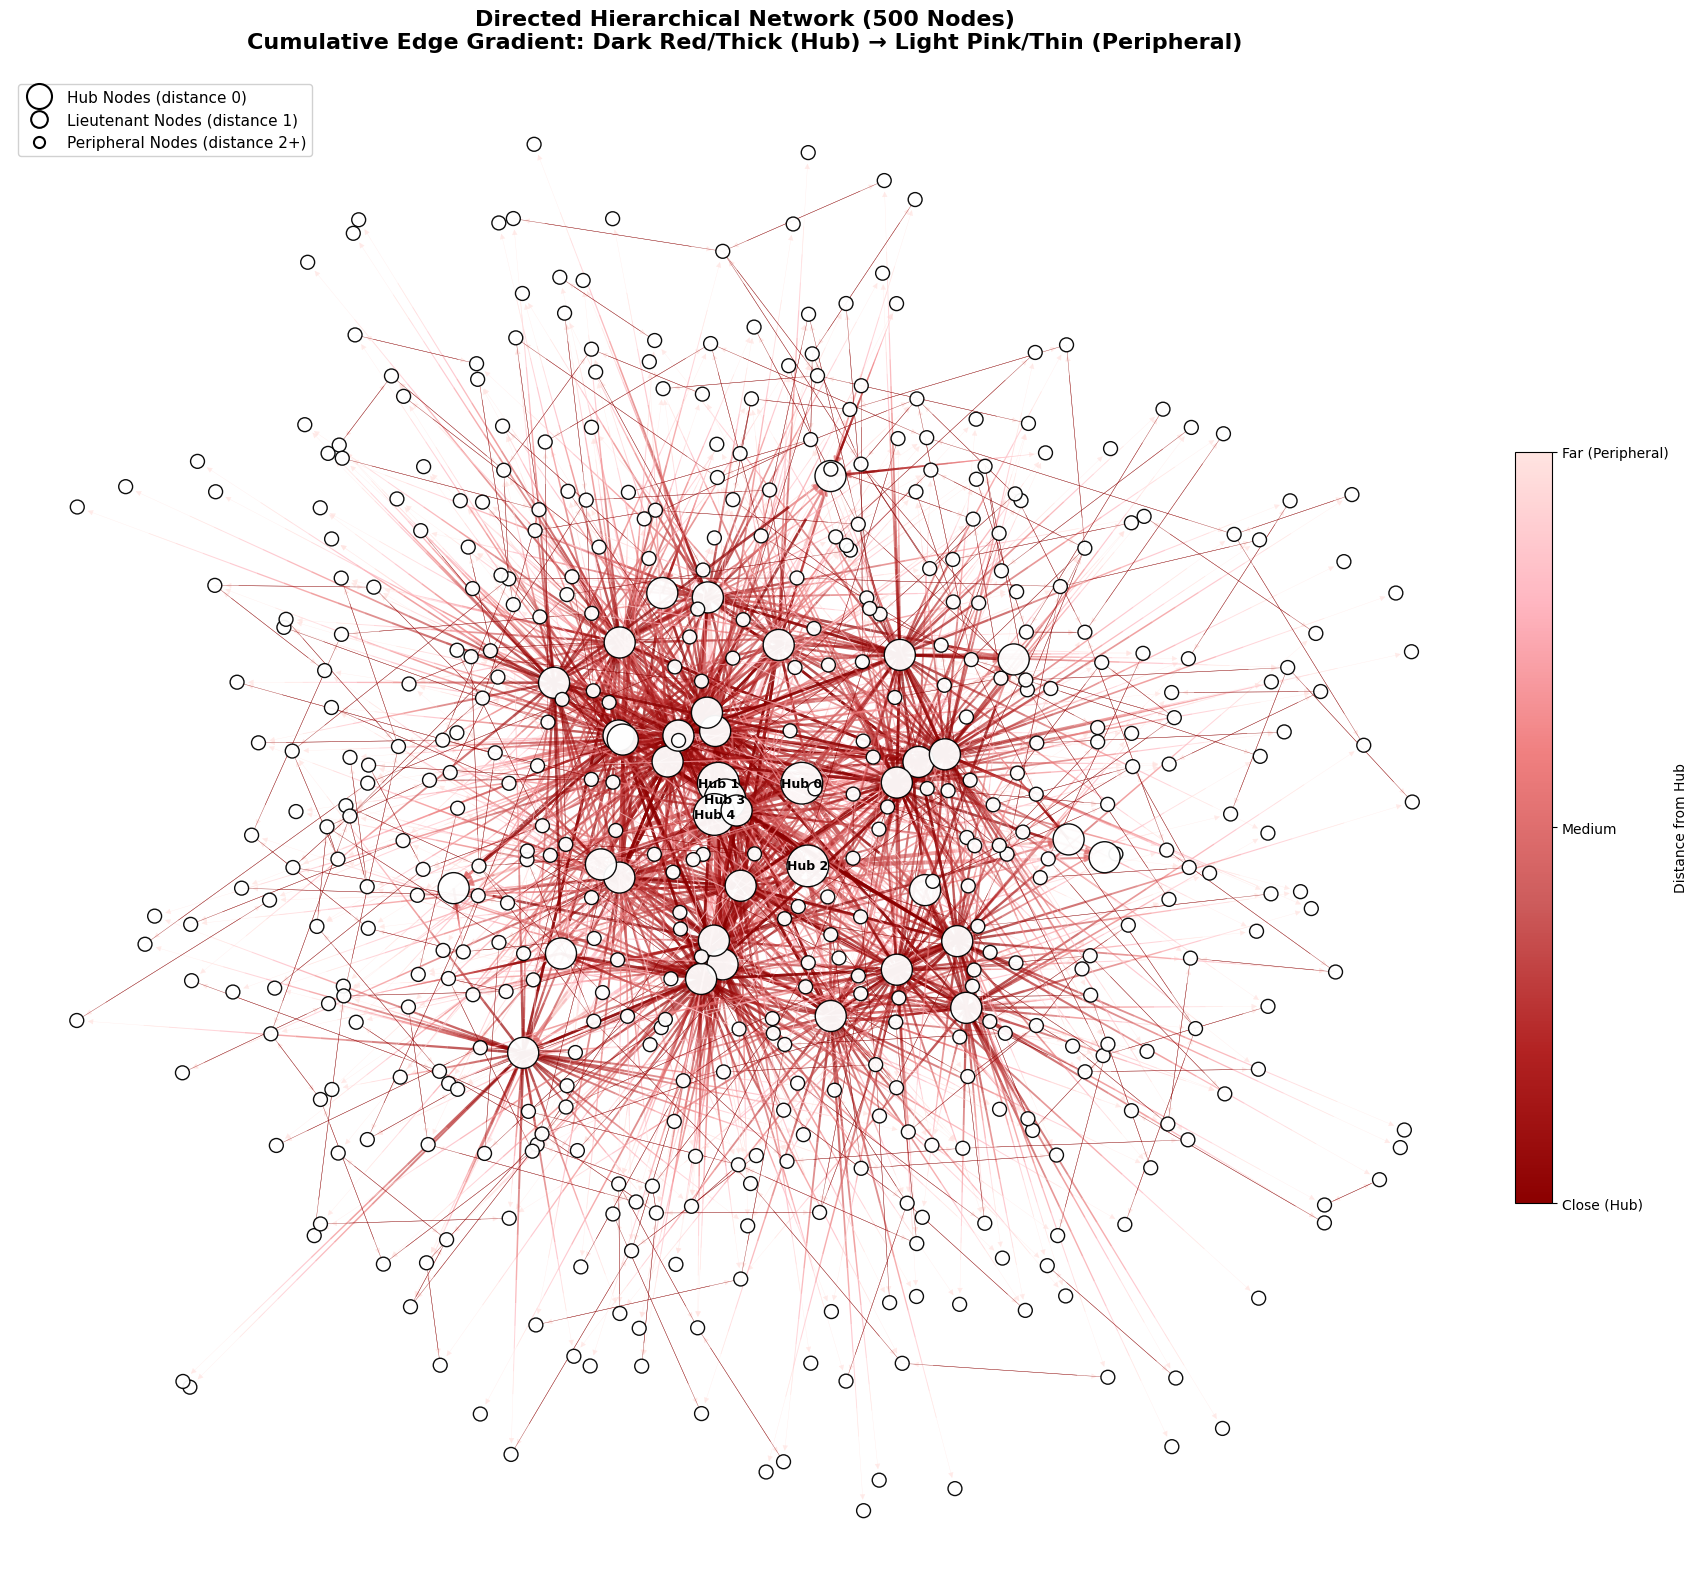

In [20]:
# Create the visualization
fig, ax = plt.subplots(figsize=(18, 16))

print("Drawing directed gradient edges with arrows (this may take a moment)...")

# Draw gradient edges with arrows (using distance-based cumulative coloring)
draw_gradient_edges_with_arrows(G, pos, norm_distance, ax)

# Draw nodes - ALL WHITE
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95,
    ax=ax,
    edgecolors='black',
    linewidths=1.0
)

# Add labels for hub nodes only
hub_labels = {node: f'Hub {node}' for node in hub_nodes}
nx.draw_networkx_labels(
    G, pos,
    labels=hub_labels,
    font_size=9,
    font_weight='bold',
    ax=ax
)

# Create colorbar for distance from hub
sm = plt.cm.ScalarMappable(cmap=red_gradient_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, label='Distance from Hub', pad=0.02)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Close (Hub)', 'Medium', 'Far (Peripheral)'])

# Create legend for node sizes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markersize=18, label=f'Hub Nodes (distance 0)', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markersize=12, label=f'Lieutenant Nodes (distance 1)', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markersize=8, label=f'Peripheral Nodes (distance 2+)', markeredgecolor='black', markeredgewidth=1.5),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

# Set title
ax.set_title(
    'Directed Hierarchical Network (500 Nodes)\n'
    'Cumulative Edge Gradient: Dark Red/Thick (Hub) → Light Pink/Thin (Peripheral)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()

# Save the figure
plt.savefig('/workspaces/graph-centrality/network_visualization.png', dpi=150, bbox_inches='tight', facecolor='white')
print("\nVisualization saved to 'network_visualization.png'")

plt.show()

## 8. Network Statistics Summary

In [13]:
# Print comprehensive network statistics
print("=" * 60)
print("NETWORK ANALYSIS SUMMARY")
print("=" * 60)
print(f"\n📊 Basic Statistics:")
print(f"   Total nodes: {G.number_of_nodes()}")
print(f"   Total edges: {G.number_of_edges()}")
print(f"   Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"   Network density: {nx.density(G):.4f}")

# Check if network is connected
if nx.is_connected(G):
    print(f"   Network is connected: Yes")
    print(f"   Diameter: {nx.diameter(G)}")
else:
    print(f"   Network is connected: No")
    print(f"   Number of components: {nx.number_connected_components(G)}")

# Centrality statistics by node type
print(f"\n📈 Average Betweenness Centrality by Node Type:")
hub_avg = np.mean([centrality[n] for n in hub_nodes])
lt_avg = np.mean([centrality[n] for n in lieutenant_nodes])
periph_avg = np.mean([centrality[n] for n in peripheral_nodes])
print(f"   Hub Nodes: {hub_avg:.6f}")
print(f"   Lieutenant Nodes: {lt_avg:.6f}")
print(f"   Peripheral Nodes: {periph_avg:.6f}")

print("\n" + "=" * 60)

NETWORK ANALYSIS SUMMARY

📊 Basic Statistics:
   Total nodes: 500
   Total edges: 1385
   Average degree: 5.54
   Network density: 0.0111
   Network is connected: Yes
   Diameter: 5

📈 Average Betweenness Centrality by Node Type:
   Hub Nodes: 0.020733
   Lieutenant Nodes: 0.061319
   Peripheral Nodes: 0.000989

